<div style="text-align: center; margin-top: 50px; margin-bottom: 30px;">
    <h1 style="font-size: 3em; color:#f54242;">Payments Data EDA</h1>
    
</div>


## For this EDA I will still be using: Google Analytics Steps

<ol style="font-size: 1.2em; color: #F3CF1D; line-height: 1.5;">
  <li><strong>Ask</strong> - Define the questions you want to answer.</li>
  <li><strong>Prepare</strong> - Collect and prepare your data for analysis.</li>
  <li><strong>Process</strong> - Clean and transform the data to ensure accuracy.</li>
  <li><strong>Analyze</strong> - Examine the data to find insights and patterns.</li>
  <li><strong>Share</strong> - Present your findings to stakeholders.</li>
  <li><strong>Act</strong> - Make decisions and take actions based on the analysis.</li>
</ol>

## 1. Ask

**Core Question:** Which features best predict how long a client will take to pay a receivable?

---

### Key EDA Questions

#### Target Variable
1. What is the distribution of payment delay (days between `due_date` and `settled_at`)?
2. What percentage of assets are paid early, on-time, or late?
3. How many assets remain unsettled (`settled_at` is NULL)?

#### Feature Relationships
4. Do higher `face_value` amounts take longer to get paid?
5. Do companies with higher `quod_score` pay faster?
6. Which industries (`main_cnae`) have the best/worst payment behavior?
7. Does `company_size` affect payment speed?

#### Data Coverage & Quality
8. What percentage of buyers/sellers have matching records in `df_company_data` and `df_quod`?
9. What is the missing value rate per column across all datasets?
10. Are there repeat buyers? Does their historical payment behavior predict future payments?


Data Glossary: 
- df_assets.parquet: Asset-level data including payment, due dates and face value. Each asset represents a installment or payment to be paid, which is linked to a invoice/order.
- df_company_data.parquet: Company basic characteristics.
- df_quod.parquet: Bureau Credit signals (periodically refreshed).
- glossary.xlsx: Dictionary containing the descriptions of each column in the above datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline


In [2]:
df_assets = pd.read_parquet('../data/raw/df_assets.parquet')
df_company_data = pd.read_parquet('../data/raw/df_company_data.parquet')
df_quod = pd.read_parquet('../data/raw/df_quod.parquet')

In [3]:
df_assets.head()

,asset_id,invoice_id,face_value,buyer_tax_id,seller_tax_id,maturity_date,due_date,settled_at,created_at,reference_date
0,5c764ad8-59dc-e30a-9d73-b051582605fb,9c3673c7cbbddde1,534.41,40199547791118,60259422305974,2025-04-10,2025-04-10,2025-04-06,2025-03-13,2025-04-15
1,b947a6c4-6e17-a418-091d-c04952f85047,23ba3b2f6e5570da,165.14,40519406990678,00925347588806,2024-12-24,2024-12-24,2024-12-22,2024-12-03,2025-03-19
2,a314edf1-9bf6-6d6c-bca5-55d1349b19d5,c2d4b28ddd0da663,432.55,38842652921056,14133781557079,2024-02-02,2024-02-02,2024-02-01,2024-01-26,2025-03-20
3,c9877d94-5168-849f-42f7-3bf4ef46bf31,2e6921011ecf24f1,102.60,54929917112999,14133781557079,2023-03-08,2023-03-08,2023-03-07,2023-02-28,2025-03-20
4,3ee1a83eb0ba837d,f32ba85be54f4160,6739.70,51211364716527,87924474238085,2024-08-08,2024-08-08,2024-08-06,2024-06-24,2025-02-03


In [4]:
df_company_data.head()

,tax_id,company_status,company_status_date,company_creation_date,company_size,main_cnae,main_cnae_description,secondary_cnae_array,legal_nature,is_mei,city,state,zipcode
7,87385337719617,Ativa,2006-06-07,2006-06-07,Demais,2621300,Fabricação de equipamentos de informática,"[{""classe"":""26.22-1"",""descricao"":""Fabricação d...",Sociedade Empresária Limitada,False,João Pessoa,Paraíba,58028870
9,48307533985873,Ativa,2016-09-29,2016-09-29,Demais,4639701,Comércio atacadista de produtos alimentícios e...,"[{""classe"":""46.49-4"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,Campo Grande,Mato Grosso do Sul,79009030
10,02003411654784,Ativa,2011-03-25,2011-03-25,Demais,4651602,Comércio atacadista de suprimentos para inform...,"[{""classe"":""46.47-8"",""descricao"":""Comércio ata...",Sociedade Simples Limitada,False,Rio de Janeiro,Rio de Janeiro,21032900
12,31629860033682,Ativa,2015-10-08,2015-10-08,Micro Empresa,4651601,Comércio atacadista de equipamentos de informá...,"[{""classe"":""47.51-2"",""descricao"":""Comércio var...",Sociedade Empresária Limitada,False,Belo Horizonte,Minas Gerais,30160040
13,85030704409437,Ativa,2022-02-28,2000-07-13,Demais,4651601,Comércio atacadista de equipamentos de informá...,"[{""classe"":""46.51-6"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,São José dos Campos,São Paulo,12231820


In [5]:
df_quod.head()

,tax_id,quod_score,presumed_revenue,created_at
0,43778071459800,578.0,2596484.57,2024-12-18 05:43:53.417114
1,59073051153497,743.0,2549628.85,2025-07-14 15:19:55.763181
2,06947646827624,448.0,54668.10,2025-02-14 21:35:02.724279
4,35820924677294,890.0,55824.92,2025-02-13 15:38:28.069201
5,90609740460747,675.0,59310.96,2025-02-14 18:36:39.512346


## 2. Prepare - Data Loading and Initial Inspection

In [6]:
# Basic data shapes and overview
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\ndf_assets: {df_assets.shape[0]:,} rows × {df_assets.shape[1]} columns")
print(f"df_company_data: {df_company_data.shape[0]:,} rows × {df_company_data.shape[1]} columns")
print(f"df_quod: {df_quod.shape[0]:,} rows × {df_quod.shape[1]} columns")

DATASET OVERVIEW

df_assets: 1,001,023 rows × 10 columns
df_company_data: 76,893 rows × 13 columns
df_quod: 55,566 rows × 4 columns


In [7]:
# Data types and missing values summary
print("\n" + "=" * 60)
print("MISSING VALUES SUMMARY")
print("=" * 60)

print("\n--- df_assets ---")
missing_assets = df_assets.isnull().sum()
print(missing_assets[missing_assets > 0])
print(f"\nTotal missing: {missing_assets.sum():,} ({missing_assets.sum()/len(df_assets)*100:.2f}%)")
print(f"Settled assets: {df_assets['settled_at'].notna().sum():,} ({df_assets['settled_at'].notna().sum()/len(df_assets)*100:.2f}%)")
print(f"Unsettled assets: {df_assets['settled_at'].isna().sum():,} ({df_assets['settled_at'].isna().sum()/len(df_assets)*100:.2f}%)")

print("\n--- df_company_data ---")
missing_company = df_company_data.isnull().sum()
print(missing_company[missing_company > 0])
print(f"\nTotal missing: {missing_company.sum():,}")

print("\n--- df_quod ---")
missing_quod = df_quod.isnull().sum()
print(missing_quod[missing_quod > 0])
print(f"\nTotal missing: {missing_quod.sum():,}")


MISSING VALUES SUMMARY

--- df_assets ---
settled_at    112519
created_at      3536
dtype: int64

Total missing: 116,055 (11.59%)
Settled assets: 888,504 (88.76%)
Unsettled assets: 112,519 (11.24%)

--- df_company_data ---
company_status            699
company_status_date      1534
company_creation_date     699
company_size              699
main_cnae                 699
main_cnae_description     699
legal_nature              699
city                      699
state                     699
zipcode                   699
dtype: int64

Total missing: 7,825

--- df_quod ---
quod_score          259
presumed_revenue    562
dtype: int64

Total missing: 821


## 3. Process - Data Cleaning and Transformation

In [8]:
# Convert date columns to datetime
df_assets['maturity_date'] = pd.to_datetime(df_assets['maturity_date'], errors='coerce')
df_assets['due_date'] = pd.to_datetime(df_assets['due_date'], errors='coerce')
df_assets['reference_date'] = pd.to_datetime(df_assets['reference_date'], errors='coerce')

# Check for date conversion issues
print(f"Date conversion issues:")
print(f"  maturity_date: {df_assets['maturity_date'].isna().sum()} NaNs")
print(f"  due_date: {df_assets['due_date'].isna().sum()} NaNs")
print(f"  reference_date: {df_assets['reference_date'].isna().sum()} NaNs")

Date conversion issues:
  maturity_date: 0 NaNs
  due_date: 0 NaNs
  reference_date: 0 NaNs


In [9]:
# Create target variable: days to payment (from due_date to settled_at)
# Only for settled assets
df_assets_settled = df_assets[df_assets['settled_at'].notna()].copy()
df_assets_settled['days_to_payment'] = (df_assets_settled['settled_at'] - df_assets_settled['created_at']).dt.days
total_assets = len(df_assets_settled)

print(f"Settled assets before dropping negatives values: {len(df_assets_settled):,}")
# I will drop rows with negative days to payment, as they are invalid
df_assets_settled = df_assets_settled[df_assets_settled['days_to_payment'] >= 0]
print(f"After dropping negatives values: ,{len(df_assets_settled):,}")
total_assets_new = len(df_assets_settled)

total_assets_dropped = total_assets - total_assets_new
print(f"Total assets dropped: {total_assets_dropped:,}")

# Payment status categories (30-day intervals representing months)
df_assets_settled['payment_status'] = pd.cut(
    df_assets_settled['days_to_payment'],
    bins=[0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, np.inf],
    labels=[
        '0-30 days',
        '31-60 days',
        '61-90 days',
        '91-120 days',
        '121-150 days',
        '151-180 days',
        '181-210 days',
        '211-240 days',
        '241-270 days',
        '271-300 days',
        '301-330 days',
        '331-360 days',
        '360+ days'
    ]
)

print(f"\nPayment Status Distribution:")
print(df_assets_settled['payment_status'].value_counts())
print(f"\nPercentage:")
print(df_assets_settled['payment_status'].value_counts(normalize=True) * 100)

Settled assets before dropping negatives values: 888,504
After dropping negatives values: ,868,256
Total assets dropped: 20,248

Payment Status Distribution:
payment_status
0-30 days       395879
31-60 days      294708
61-90 days      139644
91-120 days      18358
121-150 days      6339
151-180 days      3809
181-210 days      2752
360+ days          841
211-240 days       759
241-270 days       466
271-300 days       412
301-330 days       188
331-360 days       146
Name: count, dtype: int64

Percentage:
payment_status
0-30 days       45.803372
31-60 days      34.097843
61-90 days      16.156871
91-120 days      2.124029
121-150 days     0.733425
151-180 days     0.440703
181-210 days     0.318408
360+ days        0.097304
211-240 days     0.087817
241-270 days     0.053916
271-300 days     0.047669
301-330 days     0.021752
331-360 days     0.016892
Name: proportion, dtype: float64


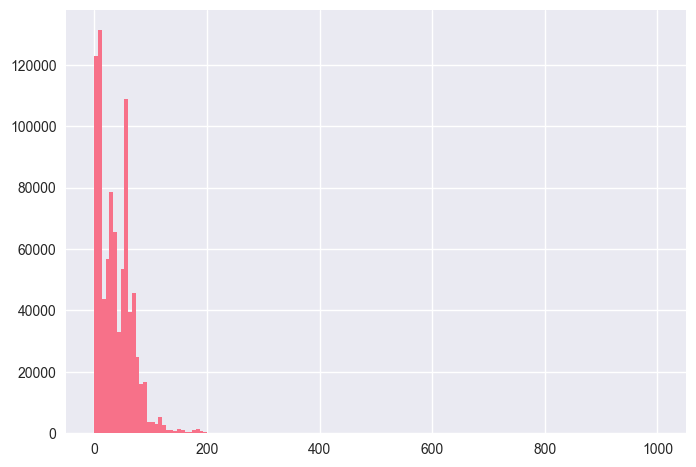

In [10]:

df_assets_settled['days_to_payment'].hist(bins=150)
plt.show()


- First Problem: We have *negative values* for a few days to payment, which means that the created_at date is wrong or the data is invalid in a few assets


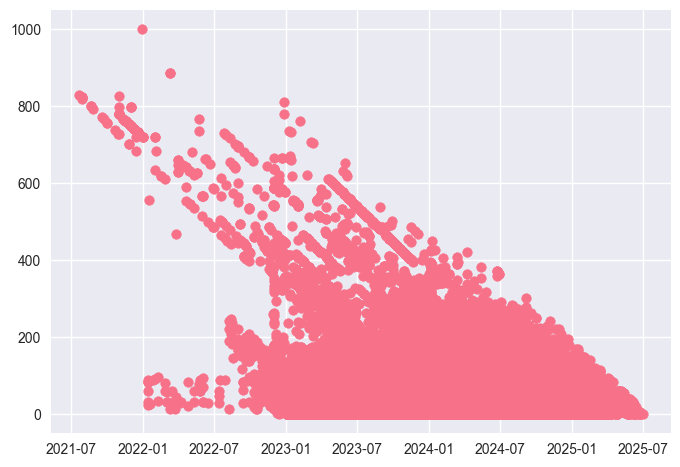

In [11]:
plt.scatter(df_assets_settled['created_at'], df_assets_settled['days_to_payment'])
plt.show()


In [12]:
# Scatter Plot is not super dense, so it is not probabily very operacional and it seems to real created at, but it certainly has 

In [13]:
# Summary statistics for days_to_payment
print("=" * 60)
print("TARGET VARIABLE: DAYS TO PAYMENT")
print("=" * 60)
print(f"\n{df_assets_settled['days_to_payment'].describe()}")

# Check for outliers
Q1 = df_assets_settled['days_to_payment'].quantile(0.25)
Q3 = df_assets_settled['days_to_payment'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_assets_settled[(df_assets_settled['days_to_payment'] < lower_bound) | 
                              (df_assets_settled['days_to_payment'] > upper_bound)]
print(f"\nOutliers (using IQR method): {len(outliers):,} ({len(outliers)/len(df_assets_settled)*100:.2f}%)")
print(f"Outlier range: [{lower_bound:.1f}, {upper_bound:.1f}] days")

TARGET VARIABLE: DAYS TO PAYMENT

count    868256.000000
mean         39.010602
std          34.902434
min           0.000000
25%          11.000000
50%          34.000000
75%          56.000000
max        1001.000000
Name: days_to_payment, dtype: float64

Outliers (using IQR method): 13,801 (1.59%)
Outlier range: [-56.5, 123.5] days


## 4. Analyze - Exploratory Data Analysis

### 4.1 Target Variable Distribution

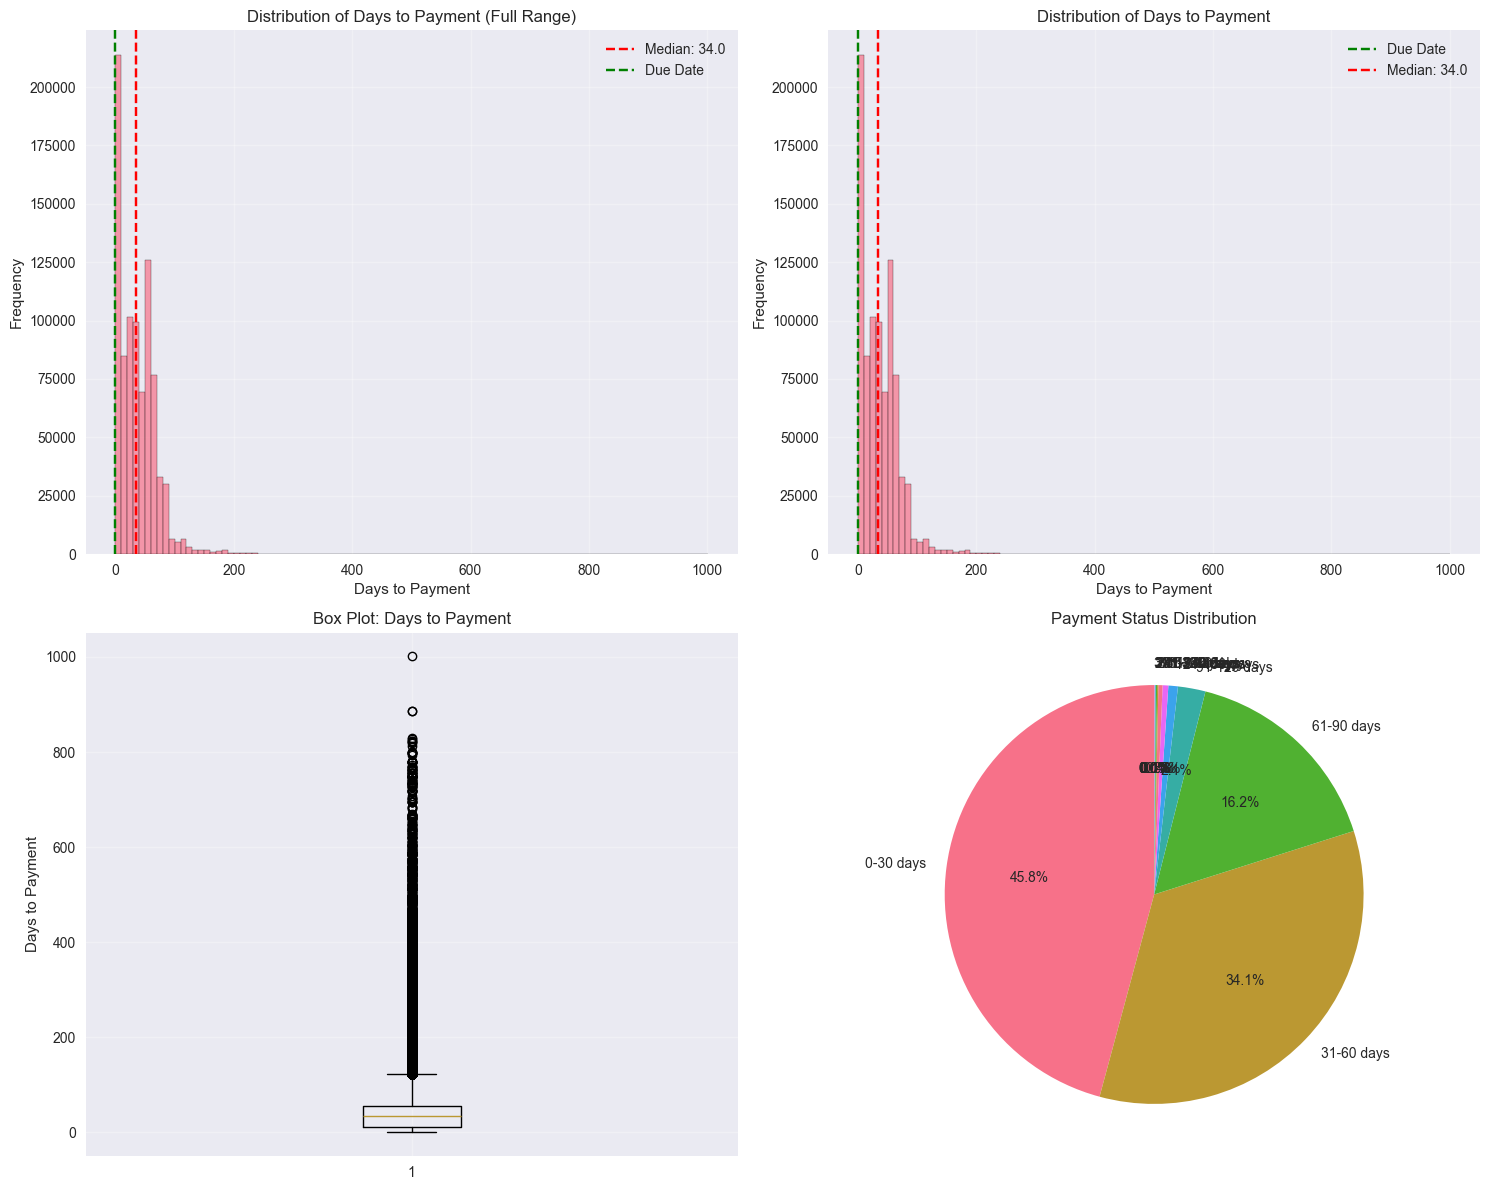

In [14]:
# Visualize distribution of days_to_payment
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram
axes[0, 0].hist(df_assets_settled['days_to_payment'], bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_assets_settled['days_to_payment'].median(), color='red', linestyle='--', 
                   label=f'Median: {df_assets_settled["days_to_payment"].median():.1f}')
axes[0, 0].axvline(0, color='green', linestyle='--', label='Due Date')
axes[0, 0].set_xlabel('Days to Payment')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Days to Payment (Full Range)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Histogram
axes[0, 1].hist(df_assets_settled['days_to_payment'], bins=100, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='green', linestyle='--', label='Due Date')
axes[0, 1].axvline(df_assets_settled['days_to_payment'].median(), color='red', linestyle='--',
                   label=f'Median: {df_assets_settled["days_to_payment"].median():.1f}')
axes[0, 1].set_xlabel('Days to Payment')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Days to Payment')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Box plot
axes[1, 0].boxplot(df_assets_settled['days_to_payment'], vert=True)
axes[1, 0].set_ylabel('Days to Payment')
axes[1, 0].set_title('Box Plot: Days to Payment')
axes[1, 0].grid(True, alpha=0.3)

# Payment status pie chart
payment_counts = df_assets_settled['payment_status'].value_counts()
axes[1, 1].pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Payment Status Distribution')

plt.tight_layout()
plt.show()

### 4.2 Face Value Analysis

FACE VALUE ANALYSIS

count    8.682560e+05
mean     1.290089e+03
std      1.535061e+04
min      0.000000e+00
25%      2.029400e+02
50%      3.556900e+02
75%      7.239300e+02
max      3.209259e+06
Name: face_value, dtype: float64


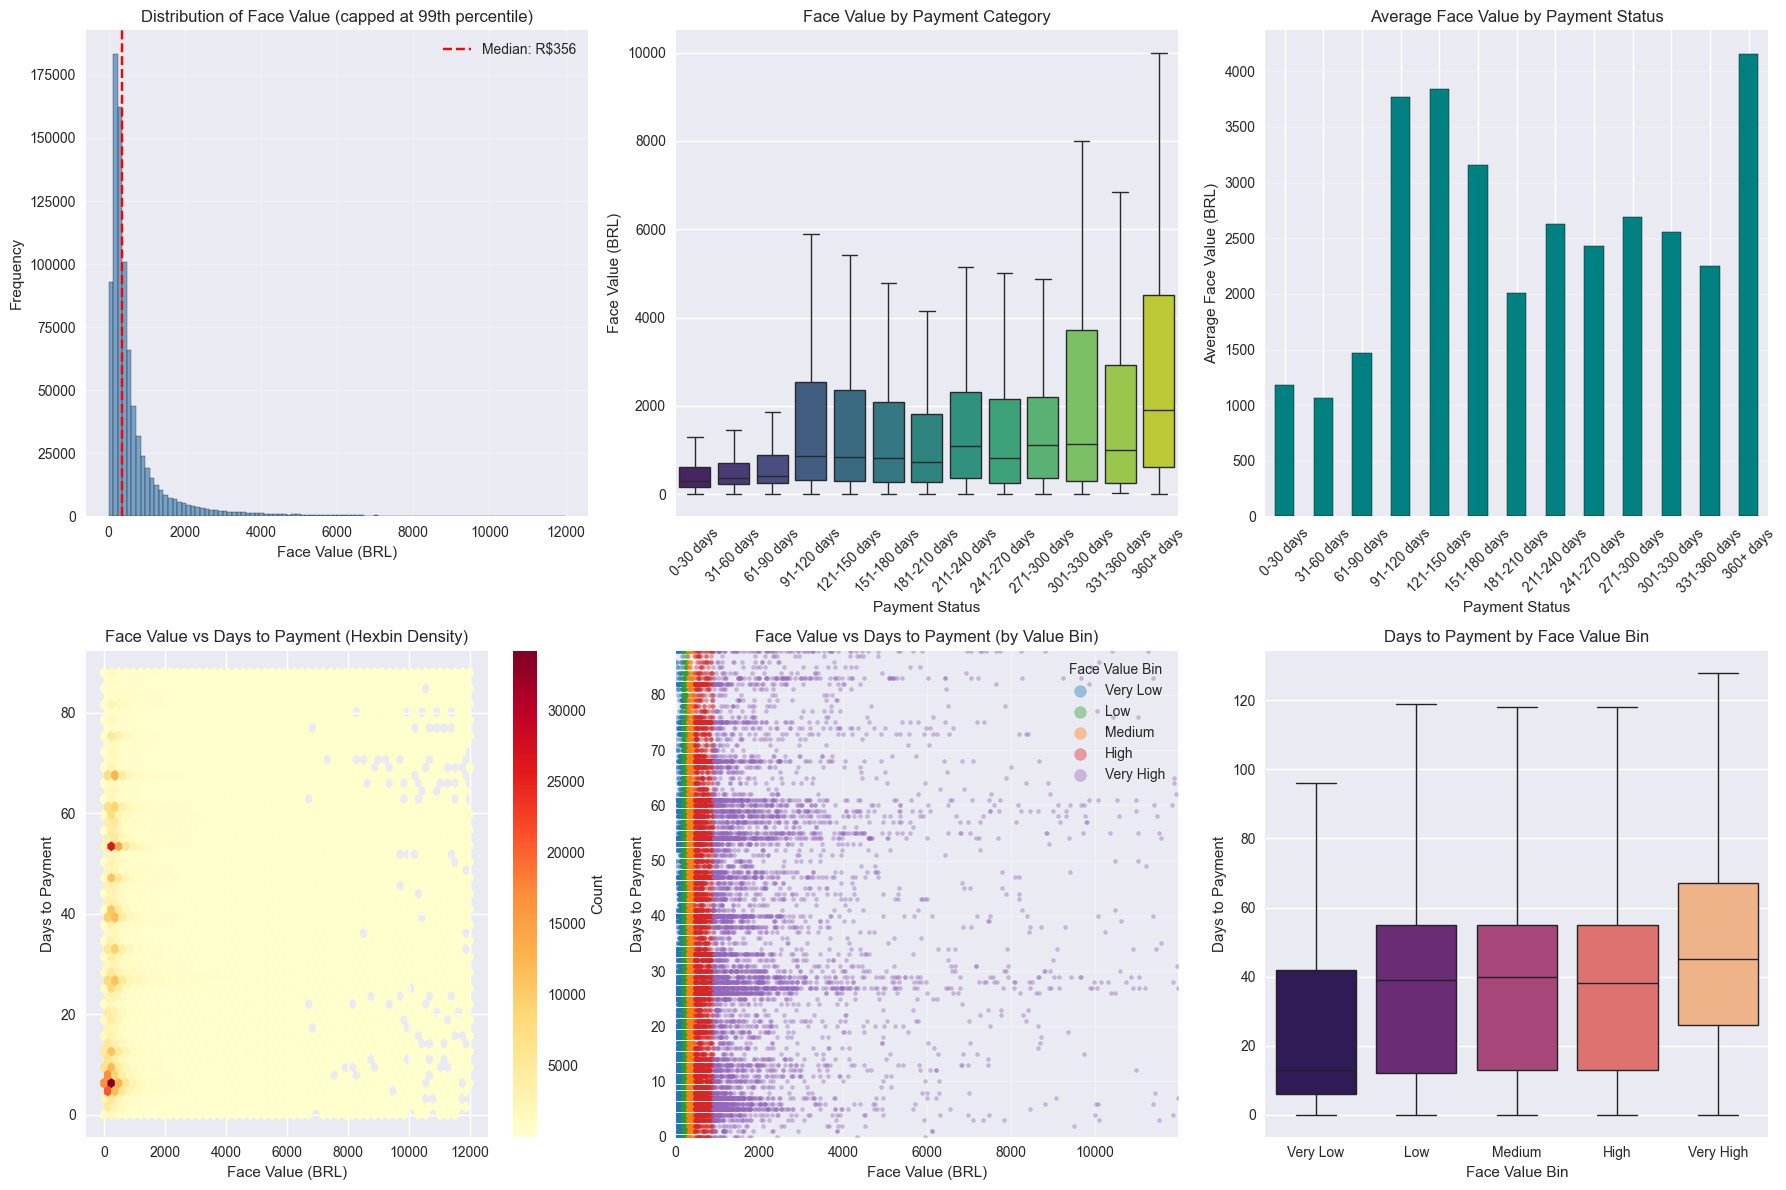


Correlation between face_value and days_to_payment: 0.0208


In [15]:
# Face value statistics
print("=" * 60)
print("FACE VALUE ANALYSIS")
print("=" * 60)
print(f"\n{df_assets_settled['face_value'].describe()}")

# Create quantile-based face value bins for better analysis
df_assets_settled['face_value_bin'] = pd.qcut(
    df_assets_settled['face_value'], 
    q=5, 
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    duplicates='drop'
)

# Face value distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Histogram of face value (capped at 99th percentile for readability)
cap_99 = df_assets_settled['face_value'].quantile(0.99)
axes[0, 0].hist(df_assets_settled[df_assets_settled['face_value'] <= cap_99]['face_value'], 
                bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_assets_settled['face_value'].median(), color='red', linestyle='--', 
                   label=f'Median: R${df_assets_settled["face_value"].median():,.0f}')
axes[0, 0].set_xlabel('Face Value (BRL)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Face Value (capped at 99th percentile)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot of face value by payment status (all categories, sorted)
category_order = ['0-30 days', '31-60 days', '61-90 days', '91-120 days', '121-150 days', 
                  '151-180 days', '181-210 days', '211-240 days', '241-270 days', 
                  '271-300 days', '301-330 days', '331-360 days', '360+ days']
palette = sns.color_palette("viridis", n_colors=len(category_order))
sns.boxplot(data=df_assets_settled, x='payment_status', y='face_value', 
            order=category_order, palette=palette, ax=axes[0, 1], showfliers=False)
axes[0, 1].set_title('Face Value by Payment Category')
axes[0, 1].set_xlabel('Payment Status')
axes[0, 1].set_ylabel('Face Value (BRL)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Mean face value by payment status
mean_by_status = df_assets_settled.groupby('payment_status')['face_value'].mean().sort_index()
mean_by_status.plot(kind='bar', ax=axes[0, 2], color='teal', edgecolor='black')
axes[0, 2].set_title('Average Face Value by Payment Status')
axes[0, 2].set_xlabel('Payment Status')
axes[0, 2].set_ylabel('Average Face Value (BRL)')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. Hexbin plot: Face Value vs Days to Payment (better for dense data)
hb = axes[1, 0].hexbin(df_assets_settled['face_value'], df_assets_settled['days_to_payment'],
                       gridsize=50, cmap='YlOrRd', mincnt=1, 
                       extent=[0, cap_99, 0, df_assets_settled['days_to_payment'].quantile(0.95)])
axes[1, 0].set_xlabel('Face Value (BRL)')
axes[1, 0].set_ylabel('Days to Payment')
axes[1, 0].set_title('Face Value vs Days to Payment (Hexbin Density)')
plt.colorbar(hb, ax=axes[1, 0], label='Count')

# 5. Scatter plot colored by face value bin (capped axes for visibility)
sample_size = min(30000, len(df_assets_settled))
sample_df = df_assets_settled.sample(n=sample_size, random_state=42)
colors = {'Very Low': '#1f77b4', 'Low': '#2ca02c', 'Medium': '#ff7f0e', 'High': '#d62728', 'Very High': '#9467bd'}
for bin_label in ['Very Low', 'Low', 'Medium', 'High', 'Very High']:
    mask = sample_df['face_value_bin'] == bin_label
    axes[1, 1].scatter(sample_df.loc[mask, 'face_value'], sample_df.loc[mask, 'days_to_payment'], 
                       alpha=0.4, s=8, label=bin_label, c=colors[bin_label])
axes[1, 1].set_xlim(0, cap_99)  # Cap x-axis at 99th percentile
axes[1, 1].set_ylim(0, df_assets_settled['days_to_payment'].quantile(0.95))  # Cap y-axis at 95th percentile
axes[1, 1].set_xlabel('Face Value (BRL)')
axes[1, 1].set_ylabel('Days to Payment')
axes[1, 1].set_title('Face Value vs Days to Payment (by Value Bin)')
axes[1, 1].legend(title='Face Value Bin', markerscale=3, loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

# 6. Days to payment distribution by face value bin
bin_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
palette_bins = sns.color_palette("magma", n_colors=5)
sns.boxplot(data=df_assets_settled, x='face_value_bin', y='days_to_payment',
            order=bin_order, palette=palette_bins, ax=axes[1, 2], showfliers=False)
axes[1, 2].set_title('Days to Payment by Face Value Bin')
axes[1, 2].set_xlabel('Face Value Bin')
axes[1, 2].set_ylabel('Days to Payment')

plt.tight_layout()
plt.show()

# Correlation
correlation = df_assets_settled['face_value'].corr(df_assets_settled['days_to_payment'])
print(f"\nCorrelation between face_value and days_to_payment: {correlation:.4f}")

### 4.3 Company Data Analysis

In [16]:
# Merge assets with company data (buyer)
df_merged_buyer = df_assets_settled.merge(
    df_company_data,
    left_on='buyer_tax_id',
    right_on='tax_id',
    how='left',
    suffixes=('', '_buyer')
)

print("=" * 60)
print("COMPANY DATA COVERAGE")
print("=" * 60)
print(f"\nBuyer coverage: {df_merged_buyer['tax_id'].notna().sum():,} / {len(df_assets_settled):,} "
      f"({df_merged_buyer['tax_id'].notna().sum()/len(df_assets_settled)*100:.2f}%)")

# Check unique buyers
unique_buyers = df_assets_settled['buyer_tax_id'].nunique()
print(f"Unique buyers in assets: {unique_buyers:,}")
print(f"Unique companies in company_data: {df_company_data['tax_id'].nunique():,}")
print(f"Overlap: {len(set(df_assets_settled['buyer_tax_id']) & set(df_company_data['tax_id'])):,}")

# Company size analysis
company_size_stats = df_merged_buyer[df_merged_buyer['company_size'].notna()].groupby('company_size').agg({
    'days_to_payment': ['mean', 'median', 'count']
}).round(2)
print("\nDays to Payment by Company Size:")
print(company_size_stats)

COMPANY DATA COVERAGE

Buyer coverage: 868,256 / 868,256 (100.00%)
Unique buyers in assets: 59,723
Unique companies in company_data: 76,893
Overlap: 59,723

Days to Payment by Company Size:
                         days_to_payment               
                                    mean median   count
company_size                                           
Demais                             42.48   31.0   71743
Empresa de Pequeno Porte           42.99   40.0  161295
Micro Empresa                      37.52   33.0  629041


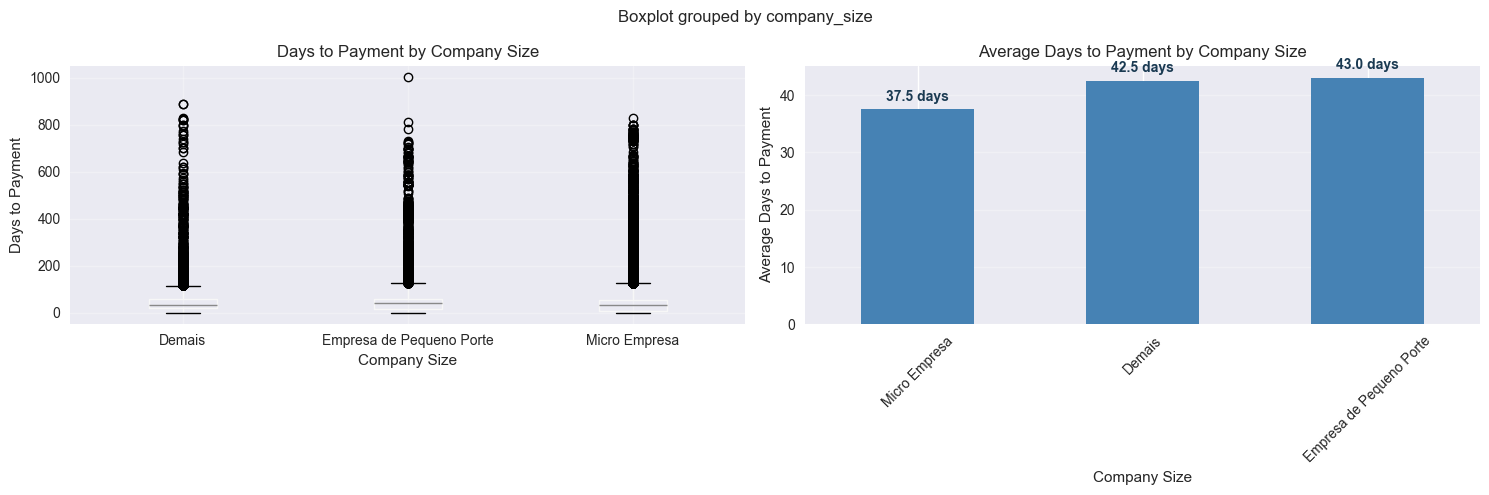

In [17]:
# Visualize company size impact
if df_merged_buyer['company_size'].notna().sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    company_size_payment = df_merged_buyer[df_merged_buyer['company_size'].notna()]
    
    # Box plot
    company_size_payment.boxplot(column='days_to_payment', by='company_size', ax=axes[0])
    axes[0].set_title('Days to Payment by Company Size')
    axes[0].set_xlabel('Company Size')
    axes[0].set_ylabel('Days to Payment')
    axes[0].grid(True, alpha=0.3)
    
    # Bar plot of means
    size_means = company_size_payment.groupby('company_size')['days_to_payment'].mean().sort_values()
    bars = size_means.plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Average Days to Payment by Company Size')
    axes[1].set_xlabel('Company Size')
    axes[1].set_ylabel('Average Days to Payment')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].tick_params(axis='x', rotation=45)
    
    # Add elegant value labels on top of bars
    axes[1].bar_label(axes[1].containers[0], fmt='%.1f days', padding=4,
                      fontsize=10, fontweight='semibold', color='#1a3a52')
    
    plt.tight_layout()
    plt.show()

In [18]:
# Top industries by payment behavior
if df_merged_buyer['main_cnae_description'].notna().sum() > 0:
    cnae_stats = df_merged_buyer[df_merged_buyer['main_cnae_description'].notna()].groupby('main_cnae_description').agg({
        'days_to_payment': ['mean', 'count']
    }).round(2)
    cnae_stats.columns = ['avg_days', 'count']
    cnae_stats = cnae_stats[cnae_stats['count'] >= 100].sort_values('avg_days')
    
    print("\nTop 10 Industries by Average Days to Payment (min 100 transactions):")
    print(cnae_stats.head(10))
    print("\nBottom 10 Industries by Average Days to Payment (min 100 transactions):")
    print(cnae_stats.tail(10))


Top 10 Industries by Average Days to Payment (min 100 transactions):
                                                    avg_days  count
main_cnae_description                                              
Atividades de assistência psicossocial e à saúd...      5.80    131
Motéis                                                  7.95    335
Fabricação de produtos derivados do cacau e de ...      7.95    307
Educação infantil - pré-escola                          8.28    171
Seleção e agenciamento de mão de obra                   8.31    131
Fabricação de massas alimentícias                       8.45   1837
Peixaria                                                8.91    193
Cantinas - serviços de alimentação privativos           8.92    639
Bares e outros estabelecimentos especializados ...      8.93   2358
Serviços ambulantes de alimentação                      9.21   3773

Bottom 10 Industries by Average Days to Payment (min 100 transactions):
                                         

### 4.4 Quod Score Analysis

In [19]:
# Merge with quod data
# For point-in-time analysis, we might want the latest quod score before the asset creation
# For simplicity, let's use the latest quod score per tax_id
df_quod_latest = df_quod.sort_values('created_at').groupby('tax_id').last().reset_index()

df_merged_quod = df_assets_settled.merge(
    df_quod_latest,
    left_on='buyer_tax_id',
    right_on='tax_id',
    how='left',
    suffixes=('', '_quod')
)

print("=" * 60)
print("QUOD SCORE COVERAGE")
print("=" * 60)
print(f"\nBuyer coverage: {df_merged_quod['quod_score'].notna().sum():,} / {len(df_assets_settled):,} "
      f"({df_merged_quod['quod_score'].notna().sum()/len(df_assets_settled)*100:.2f}%)")

if df_merged_quod['quod_score'].notna().sum() > 0:
    print(f"\nQuod Score Statistics:")
    print(df_merged_quod['quod_score'].describe())
    
    # Correlation
    correlation = df_merged_quod['quod_score'].corr(df_merged_quod['days_to_payment'])
    print(f"\nCorrelation between quod_score and days_to_payment: {correlation:.4f}")

QUOD SCORE COVERAGE

Buyer coverage: 669,941 / 868,256 (77.16%)

Quod Score Statistics:
count    669941.000000
mean        830.211169
std         168.701413
min           0.000000
25%         758.000000
50%         891.000000
75%         955.000000
max        1000.000000
Name: quod_score, dtype: float64

Correlation between quod_score and days_to_payment: 0.1024


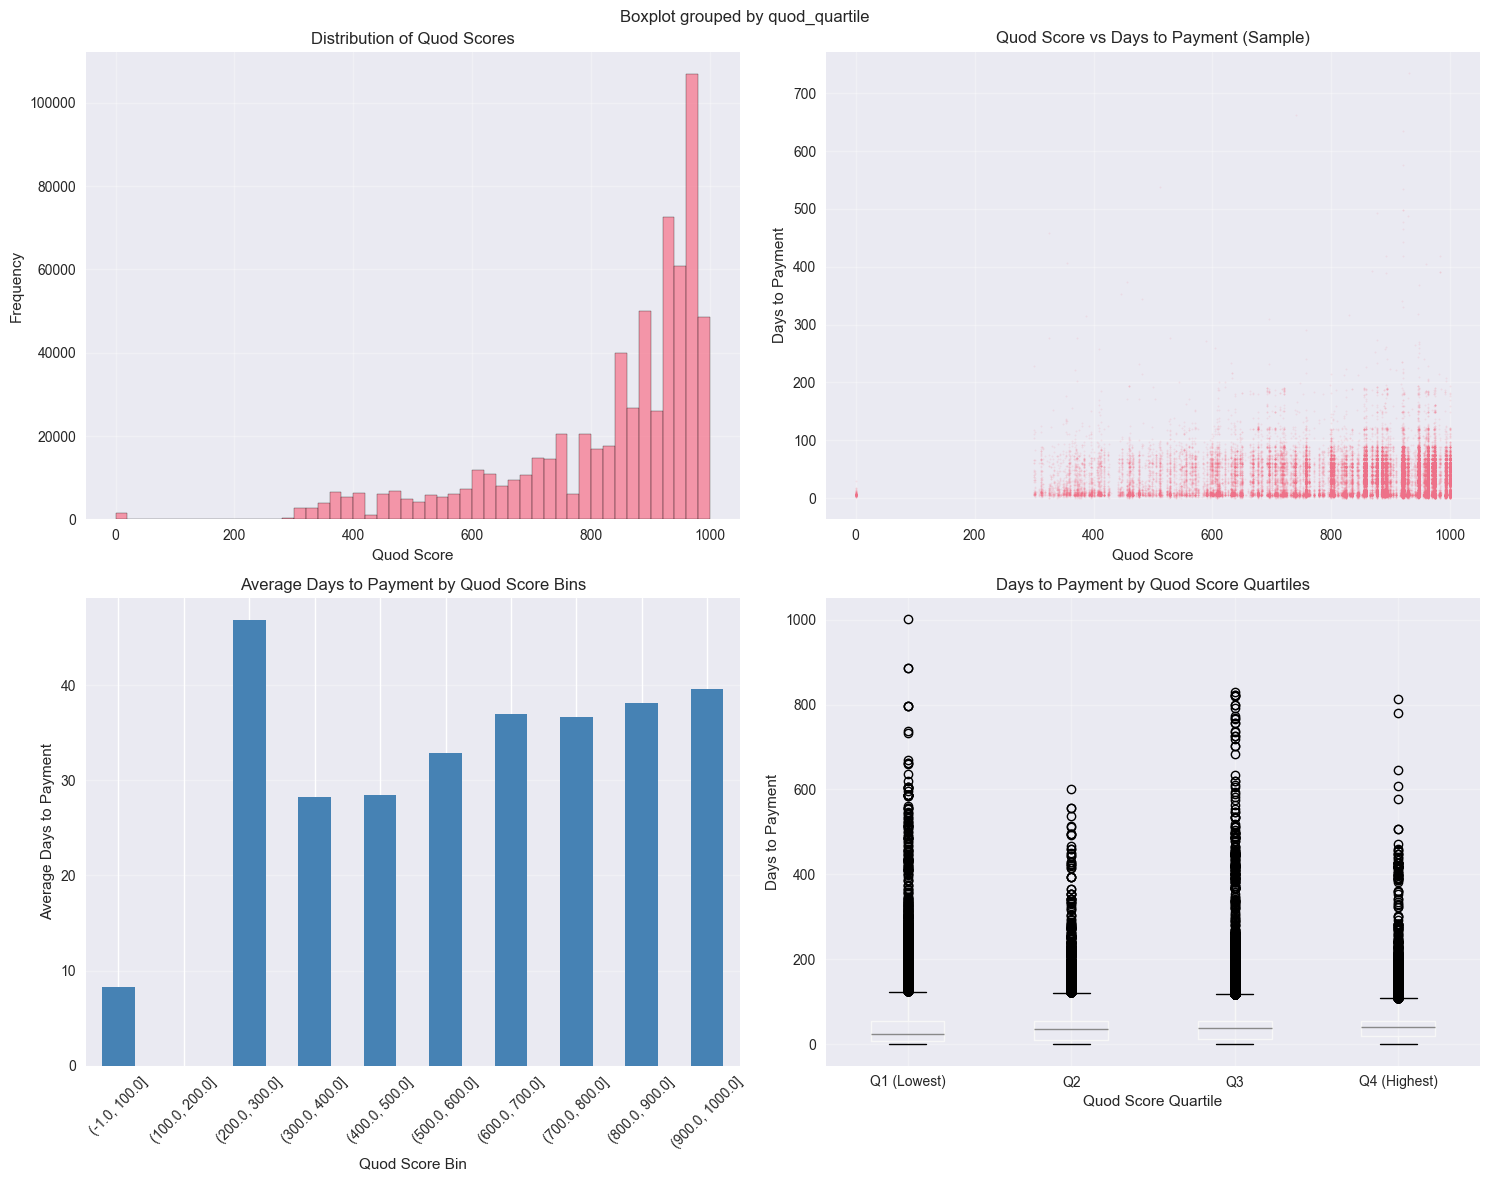

In [20]:
# Visualize quod score relationship
if df_merged_quod['quod_score'].notna().sum() > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    quod_data = df_merged_quod[df_merged_quod['quod_score'].notna()]
    
    # Histogram of quod scores
    axes[0, 0].hist(quod_data['quod_score'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Quod Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Quod Scores')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Scatter plot
    sample_size = min(50000, len(quod_data))
    sample_quod = quod_data.sample(n=sample_size, random_state=42)
    axes[0, 1].scatter(sample_quod['quod_score'], sample_quod['days_to_payment'], alpha=0.1, s=1)
    axes[0, 1].set_xlabel('Quod Score')
    axes[0, 1].set_ylabel('Days to Payment')
    axes[0, 1].set_title('Quod Score vs Days to Payment (Sample)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Binned analysis
    quod_data['quod_bin'] = pd.cut(quod_data['quod_score'], bins=10)
    bin_means = quod_data.groupby('quod_bin')['days_to_payment'].mean()
    bin_means.plot(kind='bar', ax=axes[1, 0], color='steelblue')
    axes[1, 0].set_title('Average Days to Payment by Quod Score Bins')
    axes[1, 0].set_xlabel('Quod Score Bin')
    axes[1, 0].set_ylabel('Average Days to Payment')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Box plot by quantiles
    quod_data['quod_quartile'] = pd.qcut(quod_data['quod_score'], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])
    quod_data.boxplot(column='days_to_payment', by='quod_quartile', ax=axes[1, 1])
    axes[1, 1].set_title('Days to Payment by Quod Score Quartiles')
    axes[1, 1].set_xlabel('Quod Score Quartile')
    axes[1, 1].set_ylabel('Days to Payment')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### 4.5 Time-Based Analysis

In [21]:
# Extract time features
df_assets_settled['year'] = df_assets_settled['due_date'].dt.year
df_assets_settled['month'] = df_assets_settled['due_date'].dt.month
df_assets_settled['year_month'] = df_assets_settled['due_date'].dt.to_period('M')

# Payment behavior over time
monthly_stats = df_assets_settled.groupby('year_month').agg({
    'days_to_payment': ['mean', 'median', 'count']
}).round(2)
monthly_stats.columns = ['avg_days', 'median_days', 'count']

print("=" * 60)
print("TIME-BASED ANALYSIS")
print("=" * 60)
print("\nMonthly Payment Statistics (last 12 months):")
print(monthly_stats.tail(12))

TIME-BASED ANALYSIS

Monthly Payment Statistics (last 12 months):
            avg_days  median_days  count
year_month                              
2025-12        15.75          4.0     12
2026-01         4.22          1.0     18
2026-02         2.43          1.0      7
2026-03         3.33          4.0      3
2026-04         0.00          0.0      1
2027-01        13.00         13.0      1
2027-02        13.00         13.0      1
2027-04        13.00         13.0      1
2027-05        13.00         13.0      1
2027-06        13.00         13.0      1
2027-09        13.00         13.0      1
2027-10        13.00         13.0      1


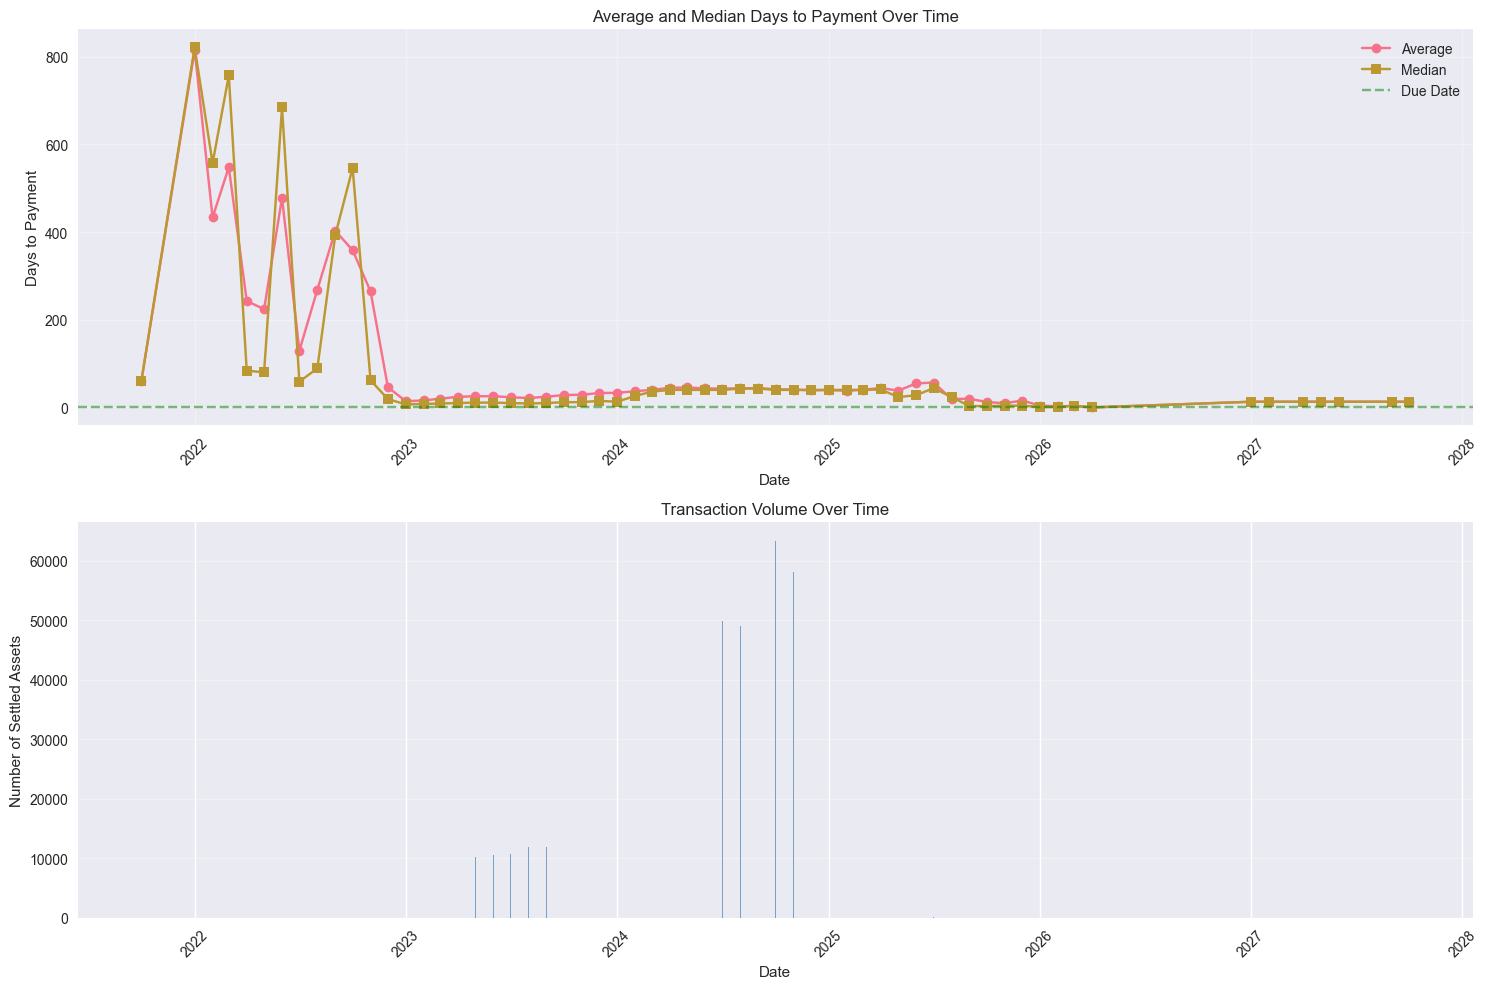

In [22]:
# Visualize trends over time
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Convert period to datetime for plotting
monthly_stats.index = monthly_stats.index.to_timestamp()

# Average days to payment over time
axes[0].plot(monthly_stats.index, monthly_stats['avg_days'], marker='o', label='Average')
axes[0].plot(monthly_stats.index, monthly_stats['median_days'], marker='s', label='Median')
axes[0].axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Due Date')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Days to Payment')
axes[0].set_title('Average and Median Days to Payment Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Transaction volume over time
axes[1].bar(monthly_stats.index, monthly_stats['count'], alpha=0.7, color='steelblue')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Settled Assets')
axes[1].set_title('Transaction Volume Over Time')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.6 Buyer Behavior Analysis

In [23]:
# Analyze repeat buyers
buyer_stats = df_assets_settled.groupby('buyer_tax_id').agg({
    'days_to_payment': ['mean', 'std', 'count'],
    'face_value': 'sum'
}).round(2)
buyer_stats.columns = ['avg_days', 'std_days', 'transaction_count', 'total_face_value']

print("=" * 60)
print("BUYER BEHAVIOR ANALYSIS")
print("=" * 60)
print(f"\nTotal unique buyers: {df_assets_settled['buyer_tax_id'].nunique():,}")
print(f"\nTransaction frequency:")
print(buyer_stats['transaction_count'].describe())

# Repeat buyers analysis
repeat_buyers = buyer_stats[buyer_stats['transaction_count'] > 1]
print(f"\nBuyers with >1 transaction: {len(repeat_buyers):,} ({len(repeat_buyers)/len(buyer_stats)*100:.2f}%)")
print(f"\nAverage days to payment by transaction count:")
print(buyer_stats.groupby(pd.cut(buyer_stats['transaction_count'], 
                                  bins=[0, 1, 5, 10, 50, np.inf],
                                  labels=['1', '2-5', '6-10', '11-50', '50+']))['avg_days'].mean())

BUYER BEHAVIOR ANALYSIS

Total unique buyers: 59,723

Transaction frequency:
count    59723.000000
mean        14.538051
std         30.723122
min          1.000000
25%          2.000000
50%          5.000000
75%         15.000000
max       1240.000000
Name: transaction_count, dtype: float64

Buyers with >1 transaction: 46,307 (77.54%)

Average days to payment by transaction count:
transaction_count
1        25.774001
2-5      29.185152
6-10     32.925196
11-50    36.370878
50+      41.125745
Name: avg_days, dtype: float64


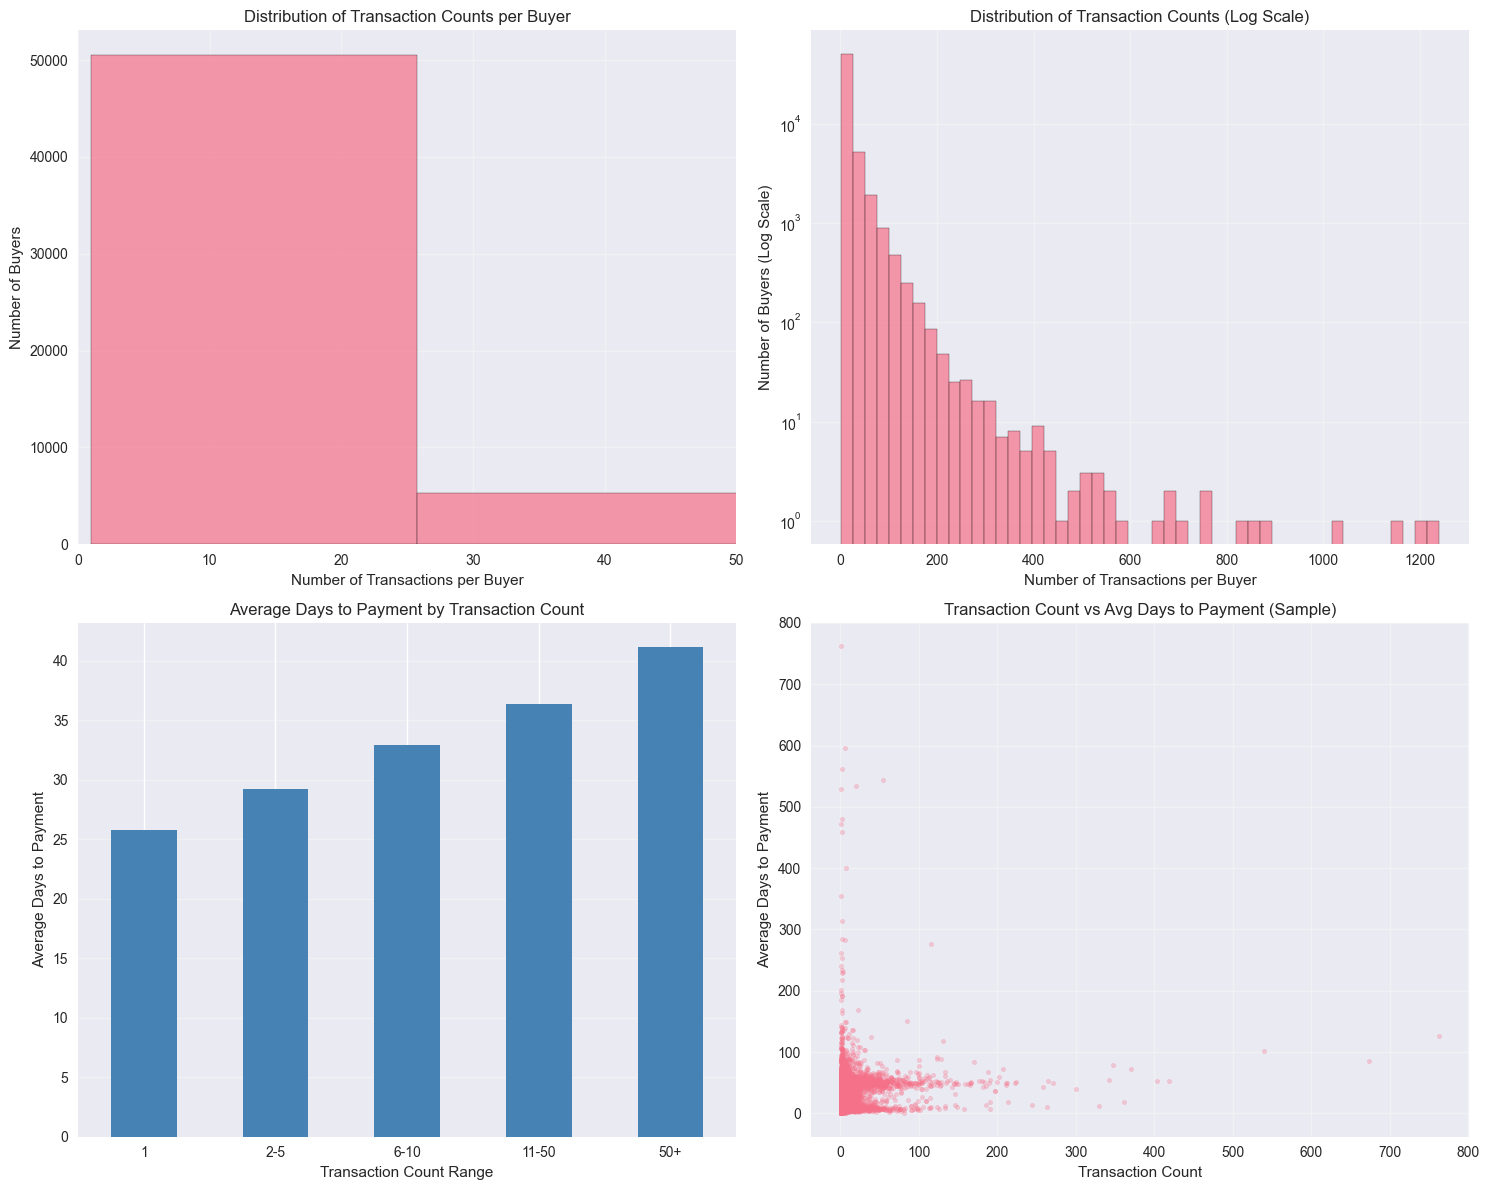

In [24]:
# Visualize buyer behavior
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Distribution of transaction counts
transaction_counts = buyer_stats['transaction_count'].value_counts().sort_index()
axes[0, 0].hist(buyer_stats['transaction_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Number of Transactions per Buyer')
axes[0, 0].set_ylabel('Number of Buyers')
axes[0, 0].set_title('Distribution of Transaction Counts per Buyer')
axes[0, 0].set_xlim(0, 50)  # Focus on first 50
axes[0, 0].grid(True, alpha=0.3)

# Log scale
axes[0, 1].hist(buyer_stats['transaction_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Number of Transactions per Buyer')
axes[0, 1].set_ylabel('Number of Buyers (Log Scale)')
axes[0, 1].set_title('Distribution of Transaction Counts (Log Scale)')
axes[0, 1].grid(True, alpha=0.3)

# Average days to payment vs transaction count
transaction_bins = pd.cut(buyer_stats['transaction_count'], 
                          bins=[0, 1, 5, 10, 50, np.inf],
                          labels=['1', '2-5', '6-10', '11-50', '50+'])
bin_means = buyer_stats.groupby(transaction_bins)['avg_days'].mean()
bin_means.plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_xlabel('Transaction Count Range')
axes[1, 0].set_ylabel('Average Days to Payment')
axes[1, 0].set_title('Average Days to Payment by Transaction Count')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=0)

# Scatter: transaction count vs avg days
sample_buyers = buyer_stats.sample(n=min(5000, len(buyer_stats)), random_state=42)
axes[1, 1].scatter(sample_buyers['transaction_count'], sample_buyers['avg_days'], alpha=0.3, s=10)
axes[1, 1].set_xlabel('Transaction Count')
axes[1, 1].set_ylabel('Average Days to Payment')
axes[1, 1].set_title('Transaction Count vs Avg Days to Payment (Sample)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.7 Comprehensive Feature Analysis

FEATURE CORRELATIONS

Correlation Matrix (numeric features):
                  face_value  quod_score  presumed_revenue  days_to_payment
face_value          1.000000    0.006859          0.106424         0.016694
quod_score          0.006859    1.000000          0.030176         0.098421
presumed_revenue    0.106424    0.030176          1.000000         0.046735
days_to_payment     0.016694    0.098421          0.046735         1.000000


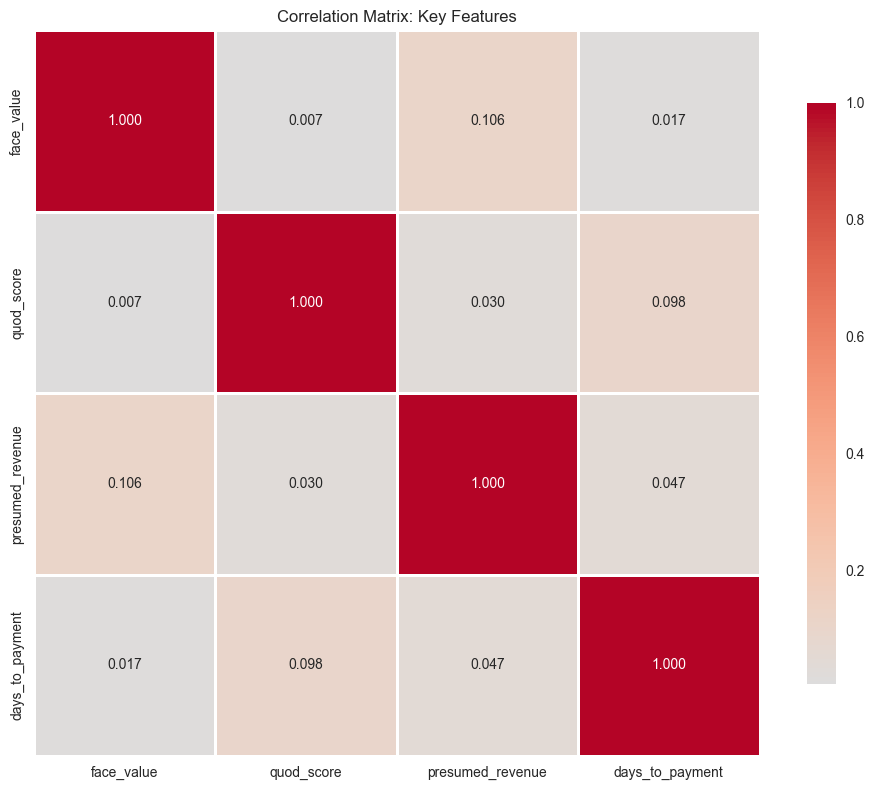

In [25]:
# Create a comprehensive dataset for analysis
df_analysis = df_assets_settled.merge(
    df_company_data,
    left_on='buyer_tax_id',
    right_on='tax_id',
    how='left',
    suffixes=('', '_buyer')
).merge(
    df_quod_latest,
    left_on='buyer_tax_id',
    right_on='tax_id',
    how='left',
    suffixes=('', '_quod')
)

# Select key numeric features for correlation analysis
numeric_features = ['face_value', 'quod_score', 'presumed_revenue', 'days_to_payment']
correlation_data = df_analysis[numeric_features].dropna()

if len(correlation_data) > 0:
    correlation_matrix = correlation_data.corr()
    
    print("=" * 60)
    print("FEATURE CORRELATIONS")
    print("=" * 60)
    print("\nCorrelation Matrix (numeric features):")
    print(correlation_matrix)
    
    # Visualize correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix: Key Features')
    plt.tight_layout()
    plt.show()

## 5. Key Findings and Summary

In [26]:
# Summary statistics
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print("\n1. DATASET SIZES:")
print(f"   - Assets: {len(df_assets):,} total, {len(df_assets_settled):,} settled ({len(df_assets_settled)/len(df_assets)*100:.1f}%)")
print(f"   - Companies: {len(df_company_data):,}")
print(f"   - Quod records: {len(df_quod):,}")

print("\n2. TARGET VARIABLE (Days to Payment):")
print(f"   - Mean: {df_assets_settled['days_to_payment'].mean():.2f} days")
print(f"   - Median: {df_assets_settled['days_to_payment'].median():.2f} days")
print(f"   - Std: {df_assets_settled['days_to_payment'].std():.2f} days")
print(f"   - Early payments (<0 days): {(df_assets_settled['days_to_payment'] < 0).sum():,} ({(df_assets_settled['days_to_payment'] < 0).sum()/len(df_assets_settled)*100:.1f}%)")
print(f"   - On-time payments (0 days): {(df_assets_settled['days_to_payment'] == 0).sum():,} ({(df_assets_settled['days_to_payment'] == 0).sum()/len(df_assets_settled)*100:.1f}%)")
print(f"   - Late payments (>0 days): {(df_assets_settled['days_to_payment'] > 0).sum():,} ({(df_assets_settled['days_to_payment'] > 0).sum()/len(df_assets_settled)*100:.1f}%)")

print("\n3. DATA COVERAGE:")
buyer_coverage = df_analysis['tax_id'].notna().sum() / len(df_assets_settled) * 100
quod_coverage = df_analysis['quod_score'].notna().sum() / len(df_assets_settled) * 100
print(f"   - Buyer company data: {buyer_coverage:.1f}%")
print(f"   - Buyer Quod score: {quod_coverage:.1f}%")

print("\n4. KEY FEATURES:")
print(f"   - Face value range: {df_assets_settled['face_value'].min():.2f} - {df_assets_settled['face_value'].max():,.2f} BRL")
print(f"   - Face value median: {df_assets_settled['face_value'].median():.2f} BRL")
if df_analysis['quod_score'].notna().sum() > 0:
    print(f"   - Quod score range: {df_analysis['quod_score'].min():.0f} - {df_analysis['quod_score'].max():.0f}")
    print(f"   - Quod score median: {df_analysis['quod_score'].median():.0f}")

print("\n5. BUYER CHARACTERISTICS:")
print(f"   - Unique buyers: {df_assets_settled['buyer_tax_id'].nunique():,}")
print(f"   - Buyers with multiple transactions: {len(repeat_buyers):,}")
print(f"   - Avg transactions per buyer: {len(df_assets_settled) / df_assets_settled['buyer_tax_id'].nunique():.2f}")

print("\n6. TEMPORAL COVERAGE:")
print(f"   - Date range: {df_assets_settled['due_date'].min()} to {df_assets_settled['due_date'].max()}")
print(f"   - Unique months: {df_assets_settled['year_month'].nunique()}")

EDA SUMMARY

1. DATASET SIZES:
   - Assets: 1,001,023 total, 868,256 settled (86.7%)
   - Companies: 76,893
   - Quod records: 55,566

2. TARGET VARIABLE (Days to Payment):
   - Mean: 39.01 days
   - Median: 34.00 days
   - Std: 34.90 days
   - Early payments (<0 days): 0 (0.0%)
   - On-time payments (0 days): 3,955 (0.5%)
   - Late payments (>0 days): 864,301 (99.5%)

3. DATA COVERAGE:
   - Buyer company data: 100.0%
   - Buyer Quod score: 77.2%

4. KEY FEATURES:
   - Face value range: 0.00 - 3,209,258.88 BRL
   - Face value median: 355.69 BRL
   - Quod score range: 0 - 1000
   - Quod score median: 891

5. BUYER CHARACTERISTICS:
   - Unique buyers: 59,723
   - Buyers with multiple transactions: 46,307
   - Avg transactions per buyer: 14.54

6. TEMPORAL COVERAGE:
   - Date range: 2021-10-25 00:00:00 to 2027-10-13 00:00:00
   - Unique months: 60


### Key Insights for Modeling

1. **Target Variable**: Days to payment shows significant variance. Many payments are early or on-time, but there's a long tail of late payments.

2. **Feature Importance Indicators**:
   - Quod score may be predictive (needs statistical testing)
   - Company size appears to have some relationship with payment behavior
   - Face value correlation is relatively weak
   - Industry (CNAE) shows variation in payment behavior

3. **Data Quality**:
   - Good coverage of settled assets for target variable creation
   - Some missing data in company and Quod datasets (need imputation strategy)
   - Temporal data available for time-based features

4. **Next Steps**:
   - Feature engineering: create aggregated buyer history features
   - Handle missing values appropriately
   - Consider time-based splits for train/test
   - Explore non-linear relationships
   - Address class imbalance if treating as classification problem